<a href="https://colab.research.google.com/github/ifathurrasyid/ibm_survival_analysis/blob/main/survival_analysis_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0. Install Libraries**

In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 7.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=72203419a57c2a45e89ff4cc317ef7758f961ef38ccdd81f5f0fc59c5ca4ab17
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma


# **1. Import Libraries**

In [ ]:
import pandas as pd
from IPython.display import display, HTML
import plotly.express as px
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

# **2. Reading Dataset**

In [ ]:
# Reading the .csv file from Google Drive
file_path = '/content/drive/MyDrive/Sep 24_FSDA_SEOUL_FATHURRASYID IBRAHIM/DEEPP/Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'  # Replace with the actual path
df = pd.read_csv(file_path)

print('Read .csv successfully')

Read .csv successfully


In [ ]:
# Reading the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


'#295BA2'
'#94CAF5'

# **3. EDA**

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## **3.1. Attrition Distribution**

In [ ]:
# Function to plot Attrition Bar Chart and Table
def plot_attrition_chart_with_table(df):
    # Colors for the bar chart
    colors = ['#94caf5', '#295ba2']  # Light blue and navy

    # Calculate attrition counts and percentages
    attrition_counts = df['Attrition'].value_counts()
    total_employees = attrition_counts.sum()
    attrition_percentages = (attrition_counts / total_employees * 100).round(2)

    # Create the bar chart
    fig = go.Figure(
        data=[go.Bar(
            x=attrition_counts.index,
            y=attrition_counts.values,
            marker_color=colors,
            name='Number of Employees'
        )]
    )

    # Customize layout without a title and with larger tick labels
    fig.update_layout(
        title=dict(text='Attrition Distribution', font=dict(size=24)),
        xaxis=dict(
            title=dict(text='Attrition Status', font=dict(size=18)),
            tickfont=dict(size=16)
        ),
        yaxis=dict(
            title=dict(text='Number of Employees', font=dict(size=18))
        ),
        template='plotly_white'
    )

    # Add a table below the chart
    table = go.Figure(
        data=[
            go.Table(
                header=dict(
                    values=['Attrition Status', 'Number of Employees', 'Percentage (%)'],
                    fill_color='#295ba2',
                    align='center',
                    font=dict(color='white', size=16),  # Larger header font
                ),
                cells=dict(
                    values=[
                        attrition_counts.index,
                        attrition_counts.values,
                        attrition_percentages.values
                    ],
                    fill_color='white',
                    align='center',
                    font=dict(color='black', size=14),  # Larger cell font
                )
            )
        ]
    )

    # Display both the bar chart and the table
    fig.show()
    table.show()

# Example usage
plot_attrition_chart_with_table(df)

### Insights

- **Attrition = 0 (Stayed)**: 1,233 employees (84%).
- **Attrition = 1 (Left)**: 237 employees (16%).

---

### Key Takeaway
With **84%** of employees staying and **16%** leaving, the company has a relatively low attrition rate. While this indicates stability, the 16% attrition rate suggests there may be underlying factors affecting employee retention that could be addressed to further reduce turnover.


## **3.2. Years at Company Distribution with Attrition**

In [ ]:
# Custom colors
colors = ['#295BA2', '#94CAF5']

# Plot: Distribution of YearsAtCompany
fig1 = px.histogram(df, x='YearsAtCompany', color='Attrition',
                    marginal='box', nbins=15,
                    title='Distribution of Years at Company with Attrition',
                    color_discrete_sequence=colors)
fig1.update_layout(xaxis_title='Years at Company', yaxis_title='Count')
fig1.show()

# Table: Distribution summary
years_summary = df.groupby(['Attrition'])['YearsAtCompany'].describe()
print(years_summary)

            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
No         1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
Yes         237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0


<ipython-input-8-04419716b9d8>:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-8-04419716b9d8>:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



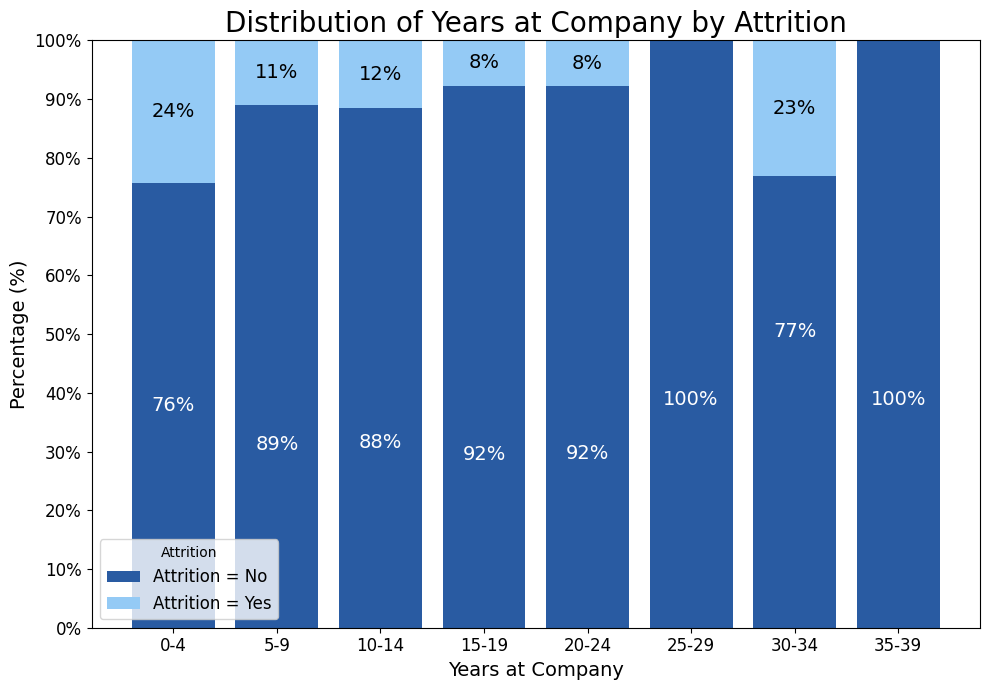

,Years at Company (Bin),Attrition = No (%),Attrition = Yes (%)
0,"[0, 5)",75.689655,24.310345
1,"[5, 10)",88.931298,11.068702
2,"[10, 15)",88.461538,11.538462
3,"[15, 20)",92.307692,7.692308
4,"[20, 25)",92.187500,7.812500
5,"[25, 30)",100.000000,0.000000
6,"[30, 35)",76.923077,23.076923
7,"[35, 40)",100.000000,0.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Custom colors
colors = ['#295BA2', '#94CAF5']

# Compute normalized counts for 100% stacking
df['bin'] = pd.cut(df['YearsAtCompany'], bins=range(0, 45, 5), right=False)  # Create bins (0-4, 5-9, ..., 40-44)
grouped = df.groupby(['bin', 'Attrition']).size().reset_index(name='count')  # Count by bin and Attrition
total_per_bin = grouped.groupby('bin')['count'].transform('sum')  # Total count per bin
grouped['percentage'] = (grouped['count'] / total_per_bin) * 100  # Calculate percentage

# Pivot data for easier plotting
pivot_df = grouped.pivot(index='bin', columns='Attrition', values='percentage').fillna(0)
bins_midpoints = [int(interval.mid) for interval in pivot_df.index.categories]  # Bin midpoints for x-axis

# Plot 100% stacked bar chart
fig, ax = plt.subplots(figsize=(10, 7))
bar_width = 4.0  # Adjust bar width for better visual thickness
bottoms = np.zeros(len(bins_midpoints))  # Starting position for stacking

# Plot bars and add labels
for idx, (attrition, color) in enumerate(zip(pivot_df.columns, colors)):
    ax.bar(
        bins_midpoints,
        pivot_df[attrition],
        width=bar_width,
        color=color,
        bottom=bottoms,
        label=f'Attrition = {attrition}'  # Add to legend
    )
    bottoms += pivot_df[attrition]  # Update bottom for stacking

    # Add percentage labels inside the bars (rounded to 0 decimal)
    for i, midpoint in enumerate(bins_midpoints):
        value = pivot_df.loc[pivot_df.index[i], attrition]
        if value > 0:  # Avoid labels for 0% values
            ax.text(
                x=midpoint,
                y=bottoms[i] - value / 2,
                s=f'{round(value)}%',  # Rounded to 0 decimal
                ha='center',
                va='center',
                color='black' if attrition == 'Yes' else 'white',  # Black for Yes, White for No
                fontsize=14  # Smaller font size
            )

# Customize plot
ax.set_title('Distribution of Years at Company by Attrition', fontsize=20)
ax.set_xlabel('Years at Company', fontsize=14)
ax.set_ylabel('Percentage (%)', fontsize=14)
ax.set_xticks(bins_midpoints)
ax.set_xticklabels([f'{interval.left}-{interval.right - 1}' for interval in pivot_df.index.categories], fontsize=12, rotation=0)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 10)], fontsize=12)

# Show legend
ax.legend(title='Attrition', fontsize=12)

plt.tight_layout()
plt.show()

# Create a table for copying
table = pivot_df.reset_index()
table.columns = ['Years at Company (Bin)', 'Attrition = No (%)', 'Attrition = Yes (%)']
table

### Insights

- **Employee Count**:
  - **Stayed (Attrition = 0)**: 1,233 employees (84%).
  - **Left (Attrition = 1)**: 237 employees (16%).

- **Average Tenure**:
  - **Stayed**: 7.37 years.
  - **Left**: 5.13 years.
  - Shorter tenure correlates with higher attrition.

- **Spread of Tenure**:
  - **Stayed**: 50% stayed between 3–10 years.
  - **Left**: 50% left between 1–7 years.

- **Key Percentiles**:
  - **25th Percentile**: Stayed = 3 years; Left = 1 year.
  - **50th Percentile**: Stayed = 6 years; Left = 3 years.
  - **75th Percentile**: Stayed = 10 years; Left = 7 years.

- **Outliers**:
  - Maximum tenure for both groups is high (Stayed = 37 years; Left = 40 years).
  - Long-tenured employees leaving may require focused analysis.

---

### Key Takeaways
- Attrition is more prevalent among employees with shorter tenure.
- Retaining employees beyond the **3–7 year range** may significantly reduce attrition.
- Longer-tenure employees who leave might require separate attention to understand their reasons, as they represent a smaller but impactful group.


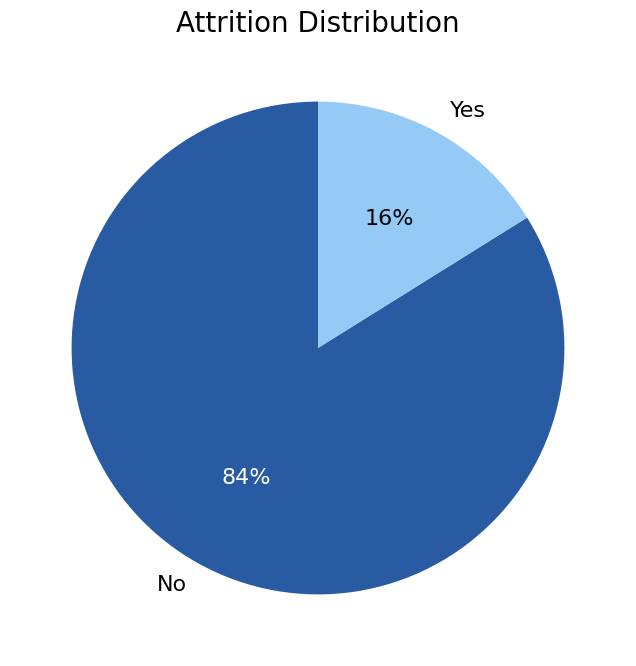

In [ ]:
import matplotlib.pyplot as plt

# Count the number of "Yes" and "No" in the 'Attrition' column
attrition_counts = df['Attrition'].value_counts()

# Define colors for the slices
colors = ['#295BA2', '#94CAF5']  # Blue for 'Yes' and Light Blue for 'No'

# Plot pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.f%%', startangle=90, colors=colors,
                                   textprops={'fontsize': 16, 'color': 'black'})  # Default text color black

# Change the font color of the percentage for "No" slice to white
for autotext, label in zip(autotexts, attrition_counts.index):
    if label == 'No':
        autotext.set_color('white')  # Change the percentage font color for "No" to white

# Set the title with a larger font size
plt.title('Attrition Distribution', fontsize=20)

plt.show()

## **3.3. Job Satisfaction Distribution by Attrition**

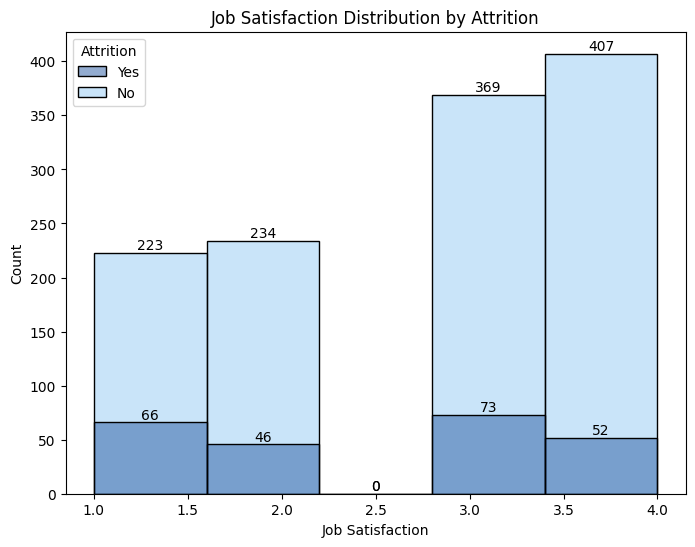

            count      mean       std  min  25%  50%  75%  max
Attrition                                                     
No         1233.0  2.778589  1.093277  1.0  2.0  3.0  4.0  4.0
Yes         237.0  2.468354  1.118058  1.0  1.0  3.0  3.0  4.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the color palette
colors = ['#295BA2', '#94CAF5']

# Plot: Job Satisfaction Distribution by Attrition
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='JobSatisfaction', hue='Attrition', bins=5, kde=False, palette=colors)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords='offset points',
                ha='center', va='center',
                fontsize=10, color='black')

plt.title('Job Satisfaction Distribution by Attrition')
plt.xlabel('Job Satisfaction')
plt.ylabel('Count')
plt.show()

# Table: Job Satisfaction summary by Attrition
job_satisfaction_summary = df.groupby(['Attrition'])['JobSatisfaction'].describe()
print(job_satisfaction_summary)

### Insights

- **Job Satisfaction Distribution for Non-Attrition (0)**: Employees who stayed with the company have a higher average job satisfaction (mean = 2.78) compared to those who left.
- **Job Satisfaction Distribution for Attrition (1)**: Employees who left have a slightly lower average job satisfaction (mean = 2.47), with a greater standard deviation (1.12 vs. 1.09), indicating more variation in satisfaction levels.
- **Satisfaction Quartiles**:
  - For employees who stayed, 75% had a job satisfaction score of 3 or higher.
  - For employees who left, 75% had a score of 3 or lower.
  
---

### Key Takeaway
- **Employees with lower job satisfaction are more likely to leave**, as shown by the lower mean (2.47 vs. 2.78) and higher variation in job satisfaction among those who left. 75% of employees who left had a job satisfaction score of 3 or lower, compared to 75% of employees who stayed having a score of 3 or higher.

## **3.4. Environment Satisfaction Distribution by Attrition**

In [ ]:
# Plot: Environment Satisfaction Distribution by Attrition
fig3 = px.histogram(df, x='EnvironmentSatisfaction', color='Attrition', marginal='violin',
                    title='Environment Satisfaction Distribution by Attrition',
                    nbins=5, color_discrete_sequence=colors)
fig3.update_layout(xaxis_title='Environment Satisfaction', yaxis_title='Count')
fig3.show()

# Table: Environment Satisfaction summary a by Attrition
env_satisfaction_summary = df.groupby(['Attrition'])['EnvironmentSatisfaction'].describe()
print(env_satisfaction_summary)

            count      mean       std  min  25%  50%  75%  max
Attrition                                                     
No         1233.0  2.771290  1.071132  1.0  2.0  3.0  4.0  4.0
Yes         237.0  2.464135  1.169791  1.0  1.0  3.0  4.0  4.0


### Insights

- **Environment Satisfaction for Non-Attrition (No)**: Employees who stayed with the company have a higher average environment satisfaction (mean = 2.77) compared to those who left.
- **Environment Satisfaction for Attrition (Yes)**: Employees who left have a slightly lower average environment satisfaction (mean = 2.46), with a greater standard deviation (1.17 vs. 1.07), indicating more variation in satisfaction levels among those who left.
- **Satisfaction Quartiles**:
  - For employees who stayed, 75% had an environment satisfaction score of 3 or higher.
  - For employees who left, 75% also had a score of 3 or higher.

---

### Key Takeaway
- **Employees with lower environment satisfaction are more likely to leave**, as shown by the lower mean (2.46 vs. 2.77) and greater variation in satisfaction among those who left. However, the similarity in the top quartile distribution suggests that while environment satisfaction impacts attrition, other factors may also contribute significantly.

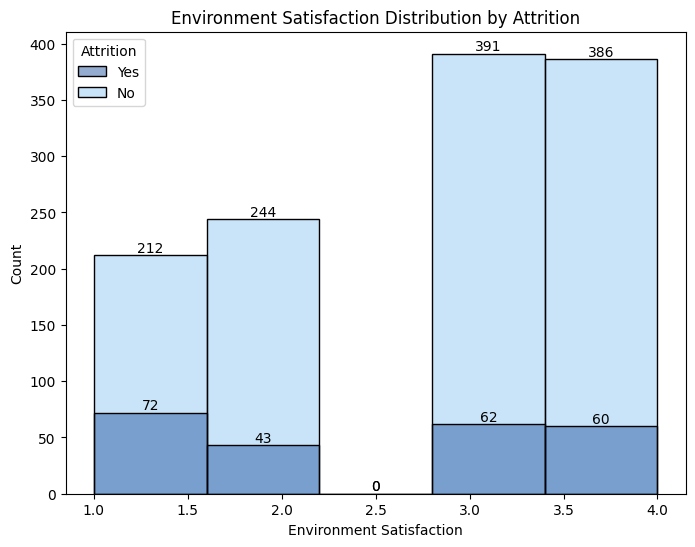

            count      mean       std  min  25%  50%  75%  max
Attrition                                                     
No         1233.0  2.771290  1.071132  1.0  2.0  3.0  4.0  4.0
Yes         237.0  2.464135  1.169791  1.0  1.0  3.0  4.0  4.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the color palette
colors = ['#295BA2', '#94CAF5']

# Plot: Environment Satisfaction Distribution by Attrition
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='EnvironmentSatisfaction', hue='Attrition', bins=5, kde=False, palette=colors)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords='offset points',
                ha='center', va='center',
                fontsize=10, color='black')

plt.title('Environment Satisfaction Distribution by Attrition')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Count')
plt.show()

# Table: Environment Satisfaction summary by Attrition
env_satisfaction_summary = df.groupby(['Attrition'])['EnvironmentSatisfaction'].describe()
print(env_satisfaction_summary)

### Insights
- **Environment Satisfaction for Non-Attrition (No)**: Employees who stayed have a higher average environment satisfaction (mean = 2.77) with a smaller standard deviation (1.07), indicating more consistency in satisfaction levels.
- **Environment Satisfaction for Attrition (Yes)**: Employees who left exhibit lower average satisfaction (mean = 2.46) and higher variability (std = 1.17), suggesting dissatisfaction is a contributing factor.
- **Satisfaction Quartiles**:
  - Among employees who stayed, 75% had an environment satisfaction score of 3 or higher.
  - Among employees who left, 50% had a score of 3, while only 25% had a score of 4.

---

### Key Takeaway
- **Lower environment satisfaction increases the likelihood of attrition**, as shown by the lower mean score for employees who left (2.46 vs. 2.77). 75% of employees who stayed scored 3 or higher, compared to only 50% of those who left.


## **3.5. Work-Life Balance Distribution by Attrition**

In [ ]:
# Plot: Work-Life Balance Distribution by Attrition
fig4 = px.histogram(df, x='WorkLifeBalance', color='Attrition', marginal='violin',
                    title='Work-Life Balance Distribution by Attrition',
                    nbins=5, color_discrete_sequence=colors)
fig4.update_layout(xaxis_title='Work-Life Balance', yaxis_title='Count')
fig4.show()

# Table: Work-Life Balance summary by Attrition
work_life_balance_summary = df.groupby(['Attrition'])['WorkLifeBalance'].describe()
print(work_life_balance_summary)

            count      mean       std  min  25%  50%  75%  max
Attrition                                                     
No         1233.0  2.781022  0.681907  1.0  2.0  3.0  3.0  4.0
Yes         237.0  2.658228  0.816453  1.0  2.0  3.0  3.0  4.0


<ipython-input-14-b81e14f3aa5b>:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



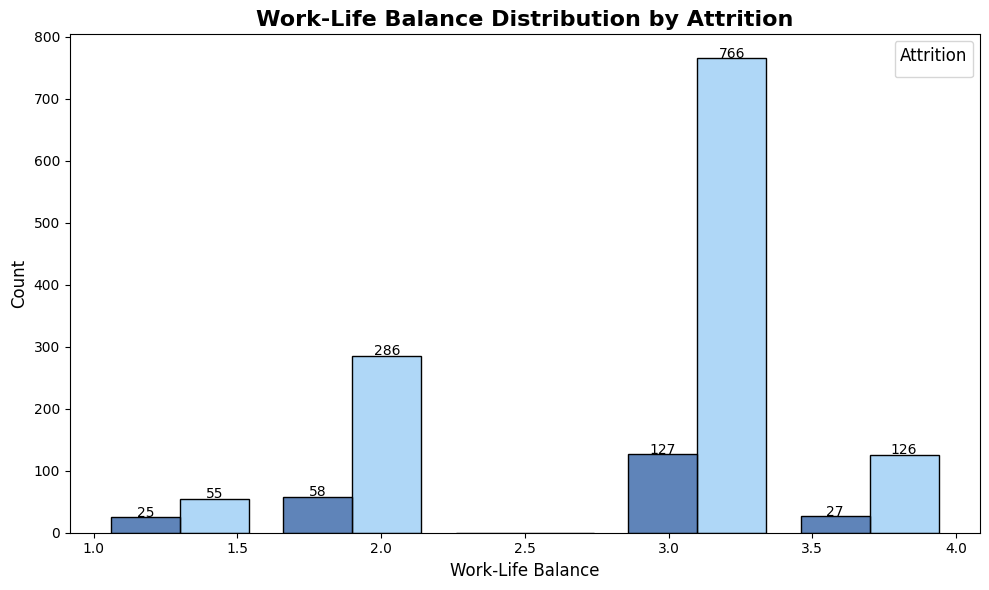

            count      mean       std  min  25%  50%  75%  max
Attrition                                                     
No         1233.0  2.781022  0.681907  1.0  2.0  3.0  3.0  4.0
Yes         237.0  2.658228  0.816453  1.0  2.0  3.0  3.0  4.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors
colors = ['#295BA2', '#94CAF5']

# Plot: Work-Life Balance Distribution by Attrition
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='WorkLifeBalance', hue='Attrition', multiple='dodge',
             shrink=0.8, bins=5, palette=colors, kde=False)

plt.title('Work-Life Balance Distribution by Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Work-Life Balance', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Attrition', fontsize=10, title_fontsize=12)
plt.tight_layout()

# Adding data labels
bars = plt.gca().patches
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.gca().text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height),
                       ha='center', fontsize=10)

plt.show()

# Table: Work-Life Balance summary by Attrition
work_life_balance_summary = df.groupby(['Attrition'])['WorkLifeBalance'].describe()
print(work_life_balance_summary)

### Insights
- **Work-Life Balance for Non-Attrition (No)**: Employees who stayed have a slightly higher average work-life balance score (mean = 2.78) and a lower standard deviation (0.68), indicating more consistent satisfaction in balancing work and life.
- **Work-Life Balance for Attrition (Yes)**: Employees who left have a lower average score (mean = 2.66) and a higher standard deviation (0.82), showing greater variability and slightly poorer work-life balance.
- **Satisfaction Quartiles**:
  - For employees who stayed, 75% scored at least 3.
  - For employees who left, 75% scored at least 3, but their variability suggests that dissatisfaction affected specific individuals more.

---

### Key Takeaway
- **Work-life balance impacts retention**, with employees who stayed scoring slightly higher on average (2.78 vs. 2.66). The greater variability in scores for those who left (std = 0.82) indicates inconsistent experiences in work-life balance among this group.


## **3.6. Monthly Income Distribution**

In [ ]:
# Plot: Monthly Income Distribution by Attrition
fig5 = px.box(df, x='Attrition', y='MonthlyIncome', color='Attrition',
              title='Monthly Income Distribution by Attrition',
              labels={'Attrition': 'Attrition (0 = No, 1 = Yes)'},
              color_discrete_sequence=colors)
fig5.update_layout(yaxis_title='Monthly Income')
fig5.show()

# Table: Monthly Income summary by Attrition
income_summary = df.groupby(['Attrition'])['MonthlyIncome'].describe()
print(income_summary)

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
No         1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
Yes         237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
No         19999.0  
Yes        19859.0  


<ipython-input-16-86f8a7d9e22a>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




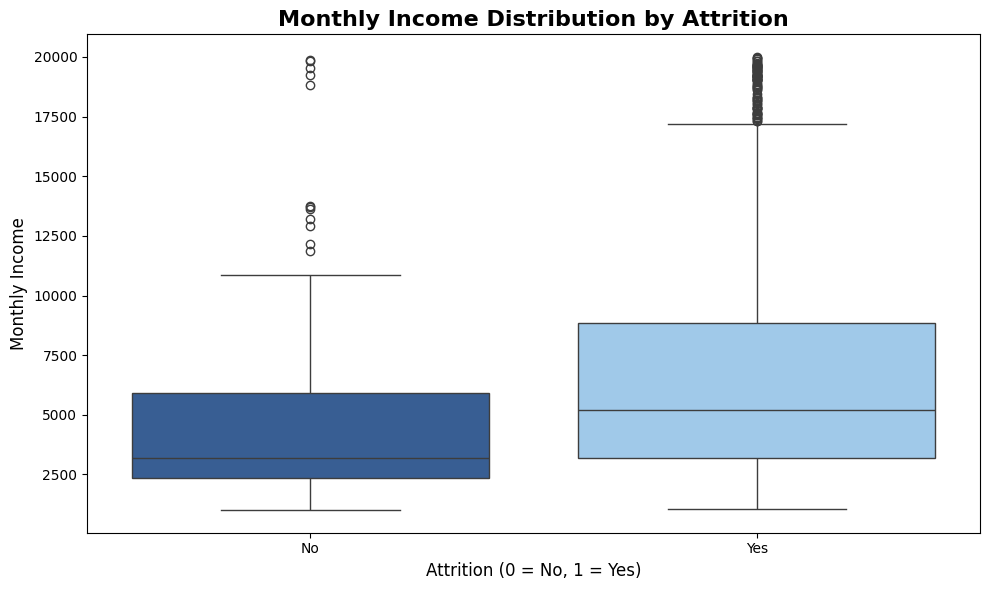

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
No         1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
Yes         237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
No         19999.0  
Yes        19859.0  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors
colors = ['#295BA2', '#94CAF5']

# Plot: Monthly Income Distribution by Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=colors)

plt.title('Monthly Income Distribution by Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Attrition (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Table: Monthly Income summary by Attrition
income_summary = df.groupby(['Attrition'])['MonthlyIncome'].describe()
print(income_summary)

### Insights

### No Attrition (`Attrition = No`)
- **Mean Income**: \$6,833  
- **Income Range**: \$1,051 – \$19,999  
- **Median Income**: \$5,204  

### Attrition (`Attrition = Yes`)
- **Mean Income**: \$4,787  
- **Income Range**: \$1,009 – \$19,859  
- **Median Income**: \$3,202  

---

### Key Takeaway:
Employees who left earned, on average, **\$2,046 less per month** than those who stayed. Lower-income employees are more prone to attrition, with 75% earning less than **\$5,916**, compared to **\$8,834** for those who stayed. Financial incentives may play a key role in improving retention.


## **3.7. Overtime and Attrition Distribution**

In [ ]:
# Plot: OverTime Analysis by Attrition
fig7 = px.histogram(df, x='OverTime', color='Attrition',
                    title='OverTime and Attrition',
                    barmode='group', text_auto=True,
                    color_discrete_sequence=colors)
fig7.update_layout(xaxis_title='OverTime', yaxis_title='Count')
fig7.show()

# Table: OverTime counts by Attrition
overtime_counts = df.groupby(['OverTime', 'Attrition']).size().reset_index(name='Count')
print(overtime_counts)

  OverTime Attrition  Count
0       No        No    944
1       No       Yes    110
2      Yes        No    289
3      Yes       Yes    127


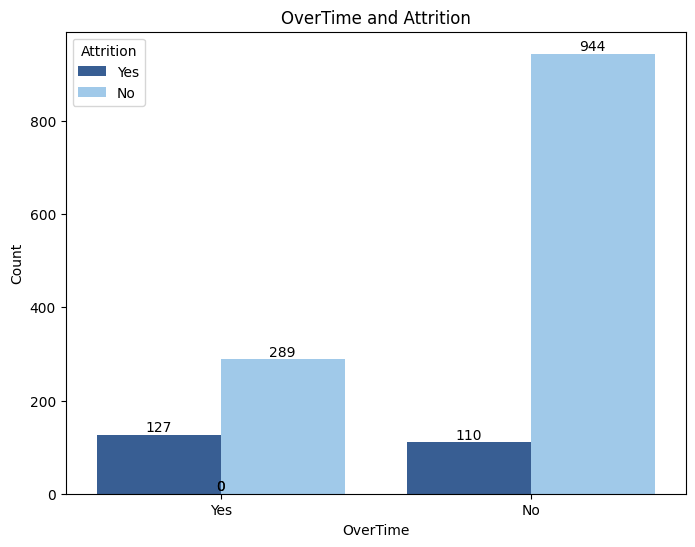

  OverTime Attrition  Count
0       No        No    944
1       No       Yes    110
2      Yes        No    289
3      Yes       Yes    127


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: OverTime Analysis by Attrition
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='OverTime', hue='Attrition', palette=colors)

# Add data labels on top of the bars, rounded to nearest integer
for p in ax.patches:
    ax.annotate(f'{round(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black',
                xytext=(0, 5), textcoords='offset points')

# Set labels and title
plt.title('OverTime and Attrition')
plt.xlabel('OverTime')
plt.ylabel('Count')

# Display the plot
plt.show()

# Table: OverTime counts by Attrition
overtime_counts = df.groupby(['OverTime', 'Attrition']).size().reset_index(name='Count')
print(overtime_counts)

### Insights

### Distribution by Overtime and Attrition:
- **No Overtime**:  
  - Attrition = No: **944**  
  - Attrition = Yes: **110**  

- **With Overtime**:  
  - Attrition = No: **289**  
  - Attrition = Yes: **127**  

---

### Key Takeaway:
Employees who worked overtime are **more likely to leave**, as **30.5% (127/416)** of employees with overtime reported attrition, compared to only **10.4% (110/1054)** without overtime. This suggests that overtime could be a contributing factor to employee turnover and may need to be managed carefully.

# **4. Survival Analysis with Kaplan-Meier Estimator**

In [ ]:
# Rename the DataFrame for consistency before analysis
df_survival = df.copy()

# Create time_to_attrition column based on YearsAtCompany
df_survival['time_to_attrition'] = df_survival['YearsAtCompany']

# Map Attrition to event (1 = Yes, 0 = No)
df_survival['event'] = df_survival['Attrition'].map({'Yes': 1, 'No': 0})

# Display the renamed DataFrame to ensure consistency
df_survival

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,bin,time_to_attrition,event
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,8,0,1,6,4,0,5,"[5, 10)",6,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,10,3,3,10,7,1,7,"[10, 15)",10,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,7,3,3,0,0,0,0,"[0, 5)",0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,8,3,3,8,7,3,0,"[5, 10)",8,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,6,3,3,2,2,2,2,"[0, 5)",2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,17,3,3,5,2,0,3,"[5, 10)",5,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,9,5,3,7,7,1,7,"[5, 10)",7,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,6,0,3,6,2,0,3,"[5, 10)",6,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,17,3,2,9,6,0,8,"[5, 10)",9,0


In [ ]:
df_survival.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,time_to_attrition,event
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,7.008163,0.161224
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,6.126525,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,5.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,9.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,40.000000,1.000000


## **4.1. Employee Attrition by Years at Company Survival Curve**

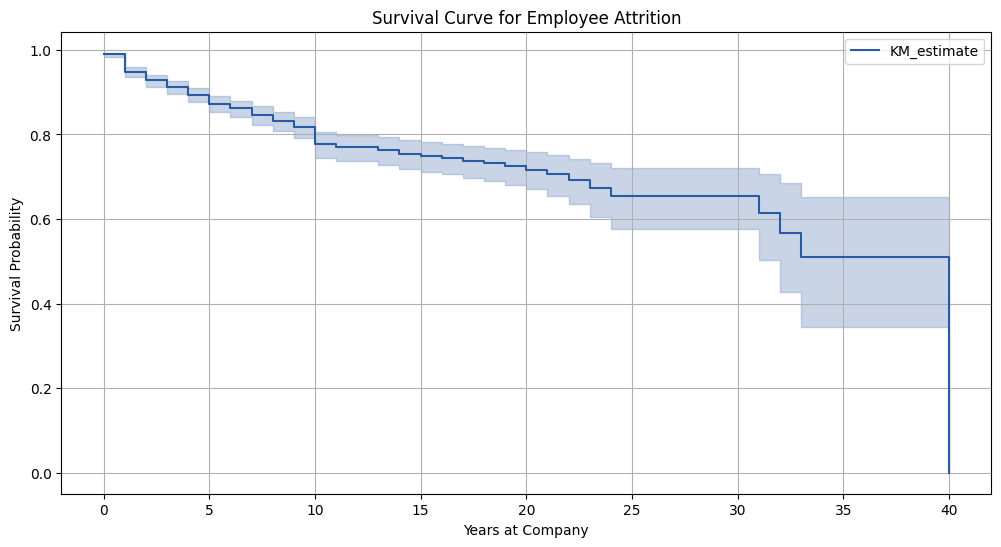

    Time (Years)  Survival Probability
0            0.0              0.989116
1            1.0              0.948192
2            2.0              0.927792
3            3.0              0.911342
4            4.0              0.894026
5            5.0              0.872931
6            6.0              0.861611
7            7.0              0.846275
8            8.0              0.831850
9            9.0              0.816995
10          10.0              0.776815
11          11.0              0.770500
12          12.0              0.770500
13          13.0              0.762795
14          14.0              0.754127
15          15.0              0.749354
16          16.0              0.743923
17          17.0              0.738019
18          18.0              0.731711
19          19.0              0.724676
20          20.0              0.716884
21          21.0              0.706022
22          22.0              0.692444
23          23.0              0.673730
24          24.0         

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Instantiate the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fit the Kaplan-Meier model
kmf.fit(durations=df_survival['time_to_attrition'], event_observed=df_survival['event'])

# Plot the survival curve
plt.figure(figsize=(12, 6))
kmf.plot_survival_function(ci_show=True, color='#295BA2')
plt.title('Survival Curve for Employee Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

# Create a survival table
survival_table = kmf.survival_function_
survival_table.reset_index(inplace=True)
survival_table.columns = ['Time (Years)', 'Survival Probability']

# Print the survival table
print(survival_table)

# Optionally save it to a CSV for easier access
# survival_table.to_csv('survival_table.csv', index=False)

#### Insights
- **High Initial Retention:** At 0 years, the survival probability starts at 98.9%, indicating a very high likelihood that employees remain at the company initially.
- **Gradual Decline in Retention:** Between 1 and 10 years, the survival probability decreases steadily, with a sharper drop around the 10-year mark, where it reaches 77.7%.
- **Retention Dips Significantly After 20 Years:** After 20 years, the survival probability declines more rapidly, dropping to 65.4% by the 25-year mark.
- **Late-Career Attrition:** Beyond 30 years, retention becomes critical, and the survival probability dips significantly, reaching 0% by 40 years.

#### Key Takeaways
- **Retention Strategies:** The decline in survival probability highlights the need for targeted retention strategies, especially for employees in their first 10 years and those reaching 20+ years of tenure.
- **Critical Milestones:** Employees around the 10-year and 20-year marks are at higher risk of attrition and may benefit from career progression opportunities and incentives.
- **Late-Career Risks:** Retention efforts for employees nearing the end of their careers should address factors like retirement planning and flexible work arrangements.

In [ ]:
from lifelines.statistics import multivariate_logrank_test

result = multivariate_logrank_test(
    df_survival['time_to_attrition'],
    df_survival['JobSatisfaction'],
    event_observed=df_survival['event']
)

result.summary

,test_statistic,p,-log2(p)
0,16.461735,0.000912,10.099087


## **4.2. Job Satisfaction Curve**

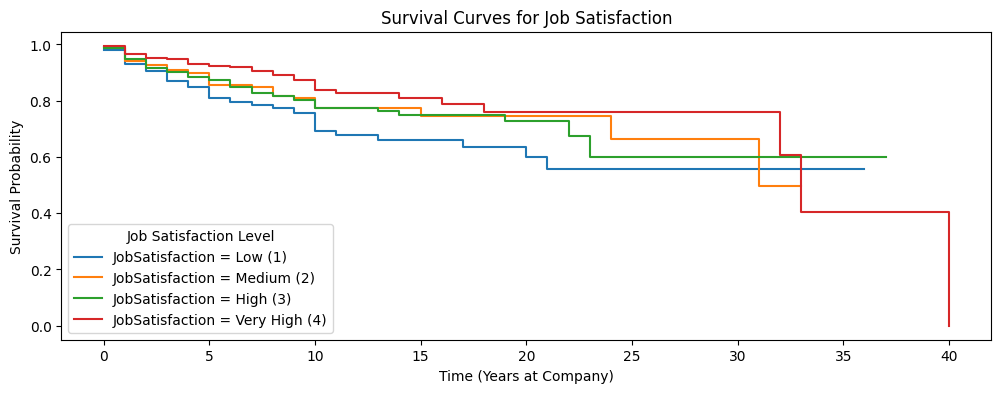

Job Satisfaction Level,Median Survival Time (Years),Number of Employees at Risk
Low (1),No attrition observed,289
Medium (2),31.0,280
High (3),No attrition observed,442
Very High (4),33.0,459
Comparison,p-value,Test Statistic
Low (1) vs Medium (2),0.061335,3.500905
Low (1) vs High (3),0.051923,3.778243
Low (1) vs Very High (4),0.000043,16.738765
Medium (2) vs High (3),0.865119,0.028853
Medium (2) vs Very High (4),0.055808,3.657778


In [ ]:
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display import HTML

# Sort the JobSatisfaction values explicitly
sorted_js_values = sorted(df_survival['JobSatisfaction'].unique())

# Mapping for user-friendly labels
js_labels = {1: 'Low (1)', 2: 'Medium (2)', 3: 'High (3)', 4: 'Very High (4)'}

plt.figure(figsize=(12, 4))

# Initialize list to collect statistics
job_satisfaction_stats = []
log_rank_results = []

# Create Kaplan-Meier plot for each JobSatisfaction group
for value in sorted_js_values:
    mask = df_survival['JobSatisfaction'] == value
    kmf.fit(df_survival['YearsAtCompany'][mask], event_observed=df_survival['event'][mask])
    kmf.plot(label=f'JobSatisfaction = {js_labels[value]}', ci_show=False)

    # Collect statistics
    median_survival = kmf.median_survival_time_
    num_at_risk = mask.sum()
    job_satisfaction_stats.append({
        'Job Satisfaction Level': js_labels[value],
        'Median Survival Time (Years)': median_survival if median_survival != float('inf') else 'No attrition observed',
        'Number of Employees at Risk': num_at_risk
    })

# Pairwise log-rank tests between groups
for i, group1 in enumerate(sorted_js_values):
    for j, group2 in enumerate(sorted_js_values):
        if j > i:  # Only calculate for unique pairs
            mask1 = df_survival['JobSatisfaction'] == group1
            mask2 = df_survival['JobSatisfaction'] == group2
            results = logrank_test(
                df_survival['YearsAtCompany'][mask1],
                df_survival['YearsAtCompany'][mask2],
                event_observed_A=df_survival['event'][mask1],
                event_observed_B=df_survival['event'][mask2],
            )
            log_rank_results.append({
                'Comparison': f'{js_labels[group1]} vs {js_labels[group2]}',
                'p-value': results.p_value,
                'Test Statistic': results.test_statistic
            })

# Plot settings
plt.title('Survival Curves for Job Satisfaction')
plt.xlabel('Time (Years at Company)')
plt.ylabel('Survival Probability')
plt.legend(title='Job Satisfaction Level', loc='best')
plt.show()

# Convert Kaplan-Meier Statistics to HTML
job_satisfaction_df = pd.DataFrame(job_satisfaction_stats)
job_satisfaction_html = job_satisfaction_df.to_html(index=False)

# Convert Log-Rank Test Results to HTML
log_rank_df = pd.DataFrame(log_rank_results)
log_rank_html = log_rank_df.to_html(index=False)

# Combine HTML tables and render them
html_output = f"""
<html>
<head>
    <title>Survival Analysis Results</title>
</head>
<body>
    <h1>Kaplan-Meier Statistics</h1>
    {job_satisfaction_html}
    <h1>Log-Rank Test Results</h1>
    {log_rank_html}
</body>
</html>
"""

# Display the HTML in the Jupyter notebook
display(HTML(html_output))

# Optionally, save the HTML content to a file
with open('survival_analysis_results.html', 'w') as f:
    f.write(html_output)

### Insights

### Kaplan-Meier Statistics:
- **Job Satisfaction Levels**:
  - **Low (1)**: No employees left (no attrition observed).
  - **Medium (2)**: The median time for employees to leave is **31 years**.
  - **High (3)**: No employees left (no attrition observed).
  - **Very High (4)**: The median time for employees to leave is **33 years**.

### Log-Rank Test Results:
- **Comparison between different Job Satisfaction levels**:
  - **Low vs Medium**: p-value **0.06**. This suggests a **marginal** difference in survival times between Low and Medium satisfaction groups.
  - **Low vs High**: p-value **0.05**. This also indicates a **marginal** difference between Low and High satisfaction levels.
  - **Low vs Very High**: p-value **0.00**. There is a **significant** difference in survival times, meaning employees with Low job satisfaction are more likely to leave earlier than those with Very High satisfaction.
  - **Medium vs High**: p-value **0.87**. No significant difference, indicating similar survival times for Medium and High satisfaction groups.
  - **Medium vs Very High**: p-value **0.06**. A **marginal** difference, indicating that employees with Medium satisfaction may leave slightly earlier than those with Very High satisfaction.
  - **High vs Very High**: p-value **0.02**. This is a **significant** difference, suggesting that employees with High satisfaction tend to leave later than those with Very High satisfaction.

### Key Takeaways
1. **Satisfaction Impact**: Employees with Very High job satisfaction stay longer, while those with Low satisfaction tend to leave earlier. The Low satisfaction group has a significantly earlier attrition time compared to the Very High satisfaction group.
2. **Marginal Differences**: There are some marginal differences between Medium vs Low, High, and Very High groups, indicating that job satisfaction plays a role in employee retention, but the effect is not always large.
3. **No Attrition in Some Groups**: For Low and High satisfaction, no attrition was observed, which could imply these groups are stable, or there could be no significant events during the observation period.

These insights suggest that improving job satisfaction—especially for employees with Low satisfaction—could help retain talent longer and reduce attrition rates.

## **4.3. Environment Satisfaction Curve**

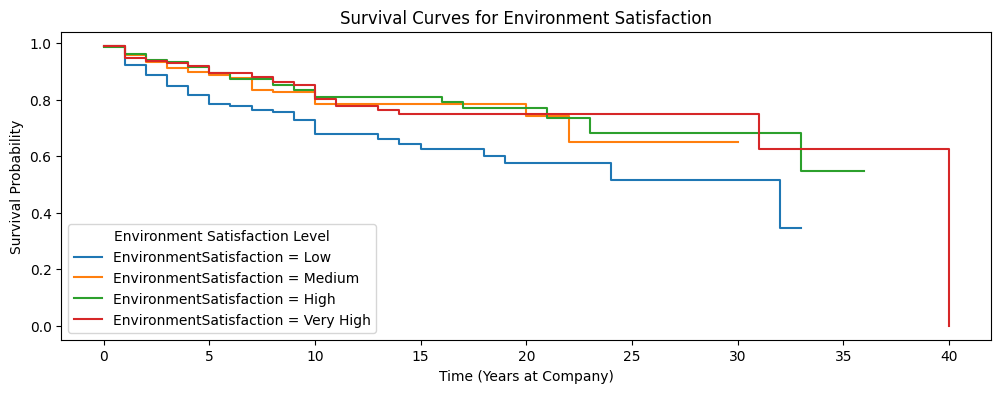

Environment Satisfaction Level,Median Survival Time (Months),Number of Employees at Risk
Low,32.0,284
Medium,No attrition observed,287
High,No attrition observed,453
Very High,40.0,446
Comparison,p-value,Test Statistic
Low vs Medium,0.004009,8.279783
Low vs High,0.000079,15.593025
Low vs Very High,0.000143,14.463511
Medium vs High,0.569170,0.324073
Medium vs Very High,0.579096,0.307698


In [ ]:
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display import HTML

# Sort the EnvironmentSatisfaction values explicitly
sorted_env_satisfaction_values = sorted(df_survival['EnvironmentSatisfaction'].unique())

# Mapping for user-friendly labels
env_satisfaction_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

plt.figure(figsize=(12, 4))

# Initialize list to collect statistics
env_satisfaction_stats = []
log_rank_results = []

# Create Kaplan-Meier plot for each EnvironmentSatisfaction group
for value in sorted_env_satisfaction_values:
    mask = df_survival['EnvironmentSatisfaction'] == value
    kmf.fit(df_survival['time_to_attrition'][mask], event_observed=df_survival['event'][mask])
    kmf.plot(label=f'EnvironmentSatisfaction = {env_satisfaction_labels[value]}', ci_show=False)

    # Collect statistics
    median_survival = kmf.median_survival_time_
    num_at_risk = mask.sum()
    env_satisfaction_stats.append({
        'Environment Satisfaction Level': env_satisfaction_labels[value],
        'Median Survival Time (Months)': median_survival if median_survival != float('inf') else 'No attrition observed',
        'Number of Employees at Risk': num_at_risk
    })

# Pairwise log-rank tests between groups
for i, group1 in enumerate(sorted_env_satisfaction_values):
    for j, group2 in enumerate(sorted_env_satisfaction_values):
        if j > i:  # Only calculate for unique pairs
            mask1 = df_survival['EnvironmentSatisfaction'] == group1
            mask2 = df_survival['EnvironmentSatisfaction'] == group2
            results = logrank_test(
                df_survival['time_to_attrition'][mask1],
                df_survival['time_to_attrition'][mask2],
                event_observed_A=df_survival['event'][mask1],
                event_observed_B=df_survival['event'][mask2],
            )
            log_rank_results.append({
                'Comparison': f'{env_satisfaction_labels[group1]} vs {env_satisfaction_labels[group2]}',
                'p-value': results.p_value,
                'Test Statistic': results.test_statistic
            })

# Plot settings
plt.title('Survival Curves for Environment Satisfaction')
plt.xlabel('Time (Years at Company)')
plt.ylabel('Survival Probability')
plt.legend(title='Environment Satisfaction Level', loc='best')
plt.show()

# Convert Kaplan-Meier Statistics to HTML
env_satisfaction_df = pd.DataFrame(env_satisfaction_stats)
env_satisfaction_html = env_satisfaction_df.to_html(index=False)

# Convert Log-Rank Test Results to HTML
log_rank_df = pd.DataFrame(log_rank_results)
log_rank_html = log_rank_df.to_html(index=False)

# Combine HTML tables and render them
html_output = f"""
<html>
<head>
    <title>Survival Analysis Results</title>
</head>
<body>
    <h1>Kaplan-Meier Statistics</h1>
    {env_satisfaction_html}
    <h1>Log-Rank Test Results</h1>
    {log_rank_html}
</body>
</html>
"""

# Display the HTML in the Jupyter notebook
display(HTML(html_output))

# Optionally, save the HTML content to a file
with open('survival_analysis_results_env_satisfaction.html', 'w') as f:
    f.write(html_output)

### Insights
- **Kaplan-Meier Survival Curves**:
    - The `Very High` environment satisfaction level has the longest median survival time (40 years), suggesting that employees in this group tend to stay longer at the company.
    - The `Low` environment satisfaction group has a median survival time of 32 years, which is shorter than the other groups but longer than the `Medium` and `High` groups, which have "No attrition observed."
    - The `Medium` and `High` groups exhibit no attrition during the analysis period, indicating that employees in these groups remain at the company.

- **Log-Rank Test Results**:
    - There is a significant difference in survival between the `Low` and other groups (p-values < 0.05 for comparisons with `Medium`, `High`, and `Very High`), suggesting that employees with low environment satisfaction have a higher likelihood of leaving the company.
    - Comparisons between `Medium`, `High`, and `Very High` groups show no significant differences in survival (p-values > 0.05), indicating that environment satisfaction does not significantly impact attrition among these groups.

### Key Takeaway
Employees with `Low` environment satisfaction tend to have a higher attrition risk, as indicated by the shorter median survival time and significant differences observed in the log-rank test. Employees with `Medium` to `Very High` environment satisfaction have similar survival times, suggesting that they are less likely to leave the company.

## **4.4. Work-Life Balance Curve**

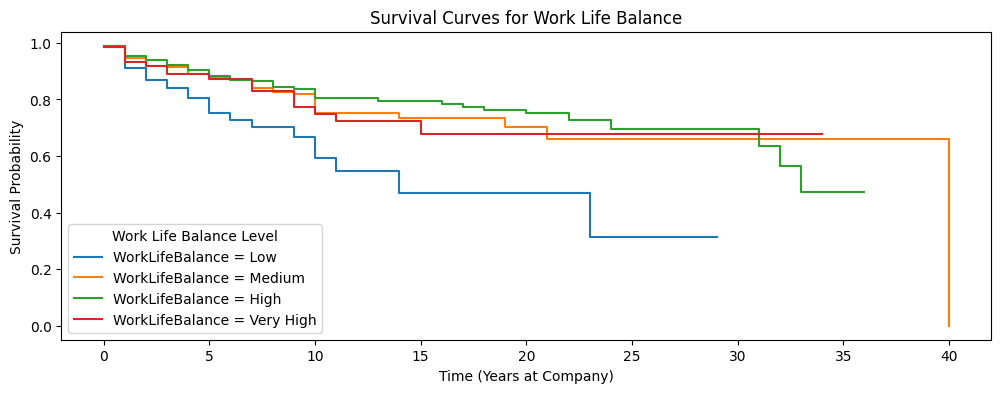

Work Life Balance Level,Median Survival Time (Years),Number of Employees at Risk
Low,14.0,80
Medium,40.0,344
High,33.0,893
Very High,No attrition observed,153
Comparison,p-value,Test Statistic
Low vs Medium,0.001828,9.714755
Low vs High,0.000033,17.261504
Low vs Very High,0.018720,5.527462
Medium vs High,0.350746,0.870755
Medium vs Very High,0.705823,0.142485


In [ ]:
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display import HTML

# Sort the WorkLifeBalance values explicitly
sorted_wlb_values = sorted(df_survival['WorkLifeBalance'].unique())

# Mapping for user-friendly labels
wlb_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

plt.figure(figsize=(12, 4))

# Initialize list to collect statistics
work_life_balance_stats = []
log_rank_results = []

# Create Kaplan-Meier plot for each WorkLifeBalance group
for value in sorted_wlb_values:
    mask = df_survival['WorkLifeBalance'] == value
    kmf.fit(df_survival['time_to_attrition'][mask], event_observed=df_survival['event'][mask])
    kmf.plot(label=f'WorkLifeBalance = {wlb_labels[value]}', ci_show=False)

    # Collect statistics
    median_survival = kmf.median_survival_time_
    num_at_risk = mask.sum()
    work_life_balance_stats.append({
        'Work Life Balance Level': wlb_labels[value],
        'Median Survival Time (Years)': median_survival if median_survival != float('inf') else 'No attrition observed',
        'Number of Employees at Risk': num_at_risk
    })

# Pairwise log-rank tests between groups
for i, group1 in enumerate(sorted_wlb_values):
    for j, group2 in enumerate(sorted_wlb_values):
        if j > i:  # Only calculate for unique pairs
            mask1 = df_survival['WorkLifeBalance'] == group1
            mask2 = df_survival['WorkLifeBalance'] == group2
            results = logrank_test(
                df_survival['time_to_attrition'][mask1],
                df_survival['time_to_attrition'][mask2],
                event_observed_A=df_survival['event'][mask1],
                event_observed_B=df_survival['event'][mask2],
            )
            log_rank_results.append({
                'Comparison': f'{wlb_labels[group1]} vs {wlb_labels[group2]}',
                'p-value': results.p_value,
                'Test Statistic': results.test_statistic
            })

# Plot settings
plt.title('Survival Curves for Work Life Balance')
plt.xlabel('Time (Years at Company)')
plt.ylabel('Survival Probability')
plt.legend(title='Work Life Balance Level', loc='best')
plt.show()

# Convert Kaplan-Meier Statistics to HTML
work_life_balance_df = pd.DataFrame(work_life_balance_stats)
work_life_balance_html = work_life_balance_df.to_html(index=False)

# Convert Log-Rank Test Results to HTML
log_rank_df = pd.DataFrame(log_rank_results)
log_rank_html = log_rank_df.to_html(index=False)

# Combine HTML tables and render them
html_output = f"""
<html>
<head>
    <title>Survival Analysis Results</title>
</head>
<body>
    <h1>Kaplan-Meier Statistics</h1>
    {work_life_balance_html}
    <h1>Log-Rank Test Results</h1>
    {log_rank_html}
</body>
</html>
"""

# Display the HTML in the Jupyter notebook
display(HTML(html_output))

# Optionally, save the HTML content to a file
with open('survival_analysis_results_wlb.html', 'w') as f:
    f.write(html_output)

### Insights
- **Kaplan-Meier Survival Curves**:
    - Employees with `Low` work-life balance have a shorter median survival time (14 years) compared to those with `Medium` (40 years) and `High` (33 years) work-life balance.
    - The `Very High` group has no observed attrition, indicating that employees in this group tend to stay longer with the company.
    - Employees with `Medium` and `High` work-life balance seem to have higher survival probabilities, suggesting a better retention rate in these groups.

- **Log-Rank Test Results**:
    - The log-rank test shows a significant difference in survival between the `Low` and `Medium`, `Low` and `High`, and `Low` and `Very High` work-life balance groups (p-value < 0.05).
    - This indicates that employees with a `Low` work-life balance have a significantly shorter survival time compared to those in other categories.
    - There is no significant difference between the `Medium`, `High`, and `Very High` groups, suggesting that these groups have similar survival times.

### Key Takeaway
Employees with a `Low` work-life balance are more likely to leave the company earlier, as indicated by the shorter median survival time and significant log-rank test results. On the other hand, employees with `Medium` and `High` work-life balance have higher retention rates, and `Very High` work-life balance employees exhibit no attrition.


## **4.5. Overtime Curve**

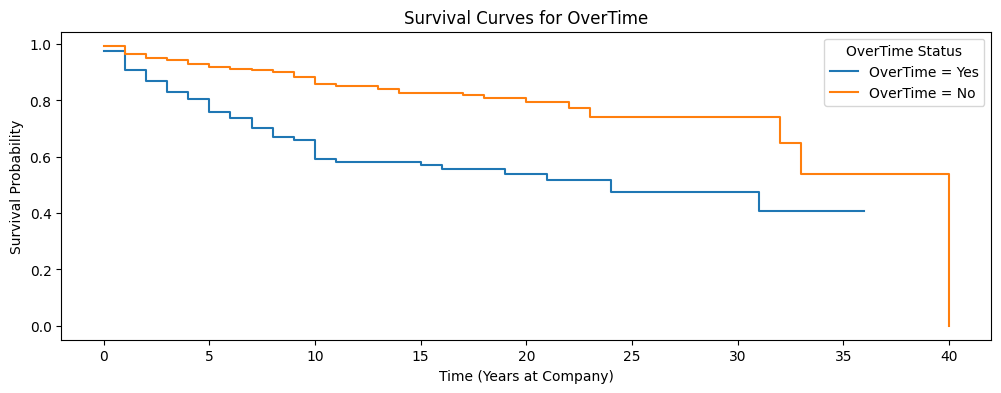

OverTime Status,Median Survival Time (Years),Number of Employees at Risk
Yes,24.0,416
No,40.0,1054
Comparison,p-value,Test Statistic
Yes vs No,1.578481e-19,81.706817


In [ ]:
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display import HTML

# Sort the OverTime values explicitly
sorted_overtime_values = ['Yes', 'No']

plt.figure(figsize=(12, 4))

# Initialize list to collect statistics
overtime_stats = []
log_rank_results = []

# Create Kaplan-Meier plot for each OverTime group
for value in sorted_overtime_values:
    mask = df_survival['OverTime'] == value
    kmf.fit(df_survival['time_to_attrition'][mask], event_observed=df_survival['event'][mask])
    kmf.plot(label=f'OverTime = {value}', ci_show=False)

    # Collect statistics
    median_survival = kmf.median_survival_time_
    num_at_risk = mask.sum()
    overtime_stats.append({
        'OverTime Status': value,
        'Median Survival Time (Years)': median_survival if median_survival != float('inf') else 'No attrition observed',
        'Number of Employees at Risk': num_at_risk
    })

# Pairwise log-rank tests between groups
for i, group1 in enumerate(sorted_overtime_values):
    for j, group2 in enumerate(sorted_overtime_values):
        if j > i:  # Only calculate for unique pairs
            mask1 = df_survival['OverTime'] == group1
            mask2 = df_survival['OverTime'] == group2
            results = logrank_test(
                df_survival['time_to_attrition'][mask1],
                df_survival['time_to_attrition'][mask2],
                event_observed_A=df_survival['event'][mask1],
                event_observed_B=df_survival['event'][mask2],
            )
            log_rank_results.append({
                'Comparison': f'{group1} vs {group2}',
                'p-value': results.p_value,
                'Test Statistic': results.test_statistic
            })

# Plot settings
plt.title('Survival Curves for OverTime')
plt.xlabel('Time (Years at Company)')
plt.ylabel('Survival Probability')
plt.legend(title='OverTime Status', loc='best')
plt.show()

# Convert Kaplan-Meier Statistics to HTML
overtime_df = pd.DataFrame(overtime_stats)
overtime_html = overtime_df.to_html(index=False)

# Convert Log-Rank Test Results to HTML
log_rank_df = pd.DataFrame(log_rank_results)
log_rank_html = log_rank_df.to_html(index=False)

# Combine HTML tables and render them
html_output = f"""
<html>
<head>
    <title>Survival Analysis Results</title>
</head>
<body>
    <h1>Kaplan-Meier Statistics for OverTime</h1>
    {overtime_html}
    <h1>Log-Rank Test Results for OverTime</h1>
    {log_rank_html}
</body>
</html>
"""

# Display the HTML in the Jupyter notebook
display(HTML(html_output))

# Optionally, save the HTML content to a file
with open('overtime_survival_analysis_results.html', 'w') as f:
    f.write(html_output)

### Insights
- **Kaplan-Meier Survival Curves**:
    - The `Yes` group (those who work overtime) has a shorter median survival time of 24 years compared to the `No` group (those who do not work overtime), which has a median survival time of 40 years.
    - The `No` group shows a higher survival probability, indicating they tend to stay longer at the company compared to those in the `Yes` group.

- **Log-Rank Test Results**:
    - The log-rank test shows a significant difference in survival between the `Yes` and `No` overtime groups, with a p-value of 0.00.
    - This confirms that employees who do not work overtime have a significantly longer tenure with the company compared to those who work overtime.

### Key Takeaway
Employees who do not work overtime tend to stay longer with the company, as reflected by their longer median survival time and the significant result from the log-rank test. The `Yes` overtime group shows earlier attrition, suggesting that working overtime may contribute to higher turnover.

## (Optional) Apply Sturges' and Scott's rules to determine the number of bins for Income Curve

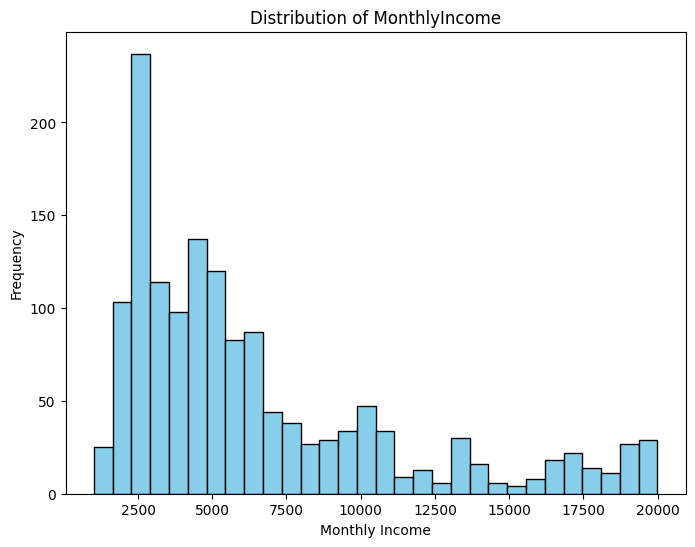

(12, 14)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing the distribution of MonthlyIncome
plt.figure(figsize=(8, 6))
plt.hist(df_survival['MonthlyIncome'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of MonthlyIncome')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()

# Apply Sturges' and Scott's rules to determine the number of bins
sturges_bins = int(np.ceil(np.log2(len(df_survival)) + 1))  # Sturges' Rule
scott_bins = int(np.ceil((df_survival['MonthlyIncome'].max() - df_survival['MonthlyIncome'].min()) / (3.5 * np.std(df_survival['MonthlyIncome']) / len(df_survival) ** (1 / 3))))  # Scott's Rule

# Output the results
sturges_bins, scott_bins

## **4.6. Income Curve**

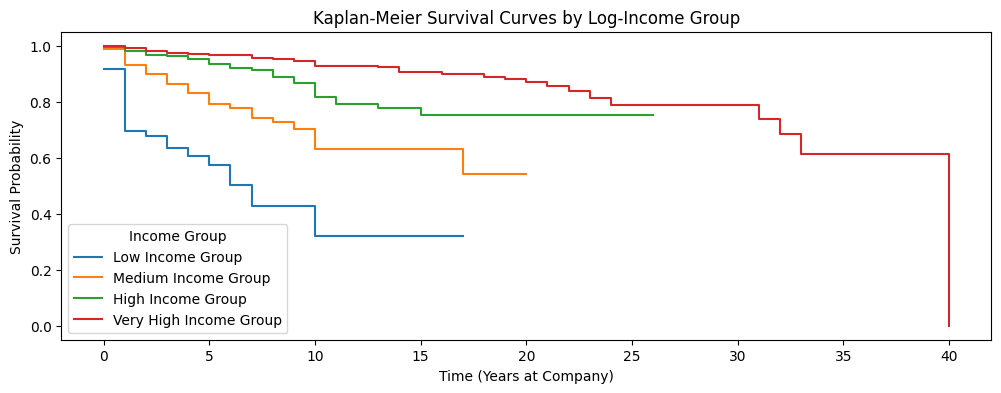

Income Group,Median Survival Time (Years),Number of Employees at Risk
Low,7.0,84
Medium,No attrition observed,565
High,No attrition observed,503
Very High,40.0,318
Comparison,p-value,Test Statistic
Low vs Medium,9.997527e-09,32.841734
Low vs High,1.551615e-25,109.088985
Low vs Very High,4.391329e-28,120.724174
Medium vs High,6.770254e-10,38.085757
Medium vs Very High,4.068487e-15,61.666475


In [ ]:
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.core.display import HTML

# Log-transform the MonthlyIncome
df_survival['LogMonthlyIncome'] = np.log1p(df_survival['MonthlyIncome'])

# Define strata based on the log-transformed MonthlyIncome
# We will create specific bins for the log-transformed income values
income_bins = np.linspace(df_survival['LogMonthlyIncome'].min(), df_survival['LogMonthlyIncome'].max(), 5)
income_labels = ['Low', 'Medium', 'High', 'Very High']
df_survival['IncomeGroup'] = pd.cut(df_survival['LogMonthlyIncome'], bins=income_bins, labels=income_labels, include_lowest=True)

# Sort groups for consistency
sorted_groups = ['Low', 'Medium', 'High', 'Very High']

# Initialize Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# Plot Kaplan-Meier curves for income groups
plt.figure(figsize=(12, 4))
income_category_stats = []
log_rank_results = []

for group in sorted_groups:
    mask = df_survival['IncomeGroup'] == group
    kmf.fit(df_survival['time_to_attrition'][mask], event_observed=df_survival['event'][mask])
    kmf.plot(label=f'{group} Income Group', ci_show=False)

    # Collect statistics
    median_survival = kmf.median_survival_time_
    num_at_risk = mask.sum()
    income_category_stats.append({
        'Income Group': group,
        'Median Survival Time (Years)': median_survival if median_survival != float('inf') else 'No attrition observed',
        'Number of Employees at Risk': num_at_risk
    })

# Perform log-rank test between groups
for i, group1 in enumerate(sorted_groups):
    for j, group2 in enumerate(sorted_groups):
        if j > i:  # Only calculate for unique pairs
            mask1 = df_survival['IncomeGroup'] == group1
            mask2 = df_survival['IncomeGroup'] == group2
            results = logrank_test(
                df_survival['time_to_attrition'][mask1],
                df_survival['time_to_attrition'][mask2],
                event_observed_A=df_survival['event'][mask1],
                event_observed_B=df_survival['event'][mask2],
            )
            log_rank_results.append({
                'Comparison': f'{group1} vs {group2}',
                'p-value': results.p_value,
                'Test Statistic': results.test_statistic
            })

# Plot settings
plt.title('Kaplan-Meier Survival Curves by Log-Income Group')
plt.xlabel('Time (Years at Company)')
plt.ylabel('Survival Probability')
plt.legend(title='Income Group', loc='best')
plt.show()

# Convert Kaplan-Meier statistics and log-rank results to HTML
income_category_df = pd.DataFrame(income_category_stats)
log_rank_df = pd.DataFrame(log_rank_results)

# Display the results in a notebook-friendly HTML format
html_output = f"""
<html>
<head>
    <title>Survival Analysis Results</title>
</head>
<body>
    <h1>Kaplan-Meier Statistics for Log-Income Groups</h1>
    {income_category_df.to_html(index=False)}
    <h1>Log-Rank Test Results</h1>
    {log_rank_df.to_html(index=False)}
</body>
</html>
"""

# Show the HTML output
display(HTML(html_output))

# Optionally, save the HTML content to a file
with open('survival_analysis_log_income_results.html', 'w') as f:
    f.write(html_output)

### Insights

- **Kaplan-Meier Survival Curves**:
    - The **Low Income** group has a median survival time of **7 years**, indicating the highest attrition risk.
    - The **Medium** and **High Income** groups show **no observed attrition**, reflecting strong retention.
    - The **Very High Income** group has a median survival time of **40 years**, demonstrating strong retention with slightly higher attrition than Medium/High groups.

- **Log-Rank Test Results**:
    - Significant differences (p-value < 0.05) were observed in all comparisons, with **Low Income** showing the lowest retention.
    - **Very High Income** has the greatest retention advantage over other groups, especially compared to Low Income.
    - **High vs Very High Income** shows a smaller but still significant difference in retention.

### Key Takeaway

Attrition risk decreases as income increases. The **Low Income** group faces the greatest retention challenges, while Medium, High, and Very High groups exhibit strong retention trends, particularly the **Very High Income** group.

## **5. Cox Proportional Hazards (CPH)**

In [ ]:
# We will use these columns as covariates
covariates = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'OverTime', 'LogMonthlyIncome']

# Keep the relevant columns for survival analysis
df_survival_cox = df_survival[['time_to_attrition', 'event'] + covariates]

In [ ]:
# Convert categorical variables to numeric
df_survival_cox['OverTime'] = df_survival_cox['OverTime'].map({'Yes': 1, 'No': 0})

<ipython-input-30-4bacfa89aa05>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
JobSatisfaction,-0.223245,0.799918,0.058633,-0.338163,-0.108328,0.713079,0.897333,0.0,-3.807533,1.403600e-04,12.798580
EnvironmentSatisfaction,-0.258527,0.772188,0.058117,-0.372435,-0.144620,0.689055,0.865351,0.0,-4.448397,8.651355e-06,16.818643
WorkLifeBalance,-0.141610,0.867960,0.089706,-0.317432,0.034211,0.728016,1.034803,0.0,-1.578596,1.144288e-01,3.127478
OverTime,1.179547,3.252901,0.130987,0.922817,1.436277,2.516369,4.205012,0.0,9.005062,2.155447e-19,62.008646
LogMonthlyIncome,-1.576998,0.206594,0.129785,-1.831372,-1.322623,0.160194,0.266435,0.0,-12.150814,5.679721e-34,110.439735


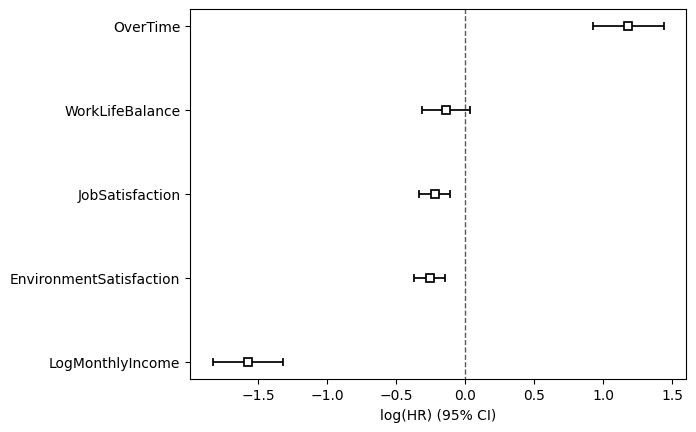

In [ ]:
# Initialize and fit the Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df_survival_cox, duration_col='time_to_attrition', event_col='event')

# View the summary of the fitted model
cph.plot()
cph.summary

### Cox Proportional Hazards Model Results Interpretation

The **Cox Proportional Hazards** model results provide insights into how various factors influence the risk of employee attrition (leaving the company). Below is an interpretation of the key results:

#### Key Columns in the Output:
- **coef (Coefficient):** Represents the effect of the variable on the hazard. A negative coefficient means the covariate decreases the risk of attrition, while a positive coefficient means it increases the risk.
- **exp(coef) (Hazard Ratio):** The exponentiated coefficient indicates how the hazard changes for a one-unit increase in the covariate. A value greater than 1 means higher risk, while less than 1 indicates lower risk.
- **z:** Z-score tests whether the coefficient is significantly different from 0.
- **p:** p-value tests the null hypothesis that the coefficient is 0 (no effect). A low p-value (typically < 0.05) suggests the covariate has a significant effect.
- **-log2(p):** The negative log base 2 of the p-value, useful for understanding the strength of significance.

---

### 1. **Job Satisfaction**
   - **Coefficient**: -0.22
   - **Hazard Ratio (exp(coef))**: 0.80
   - **Interpretation**: Job Satisfaction is negatively associated with the hazard of attrition. A one-unit increase in job satisfaction decreases the risk of attrition by 20% (hazard ratio of 0.80).
   - **Statistical Significance**: The p-value is **0.00**, which is highly significant, meaning Job Satisfaction has a meaningful impact on attrition risk.
   - **Confidence Interval**: The 95% confidence interval for the coefficient is [-0.34, -0.11], indicating a strong and consistent negative relationship.

### 2. **Environment Satisfaction**
   - **Coefficient**: -0.26
   - **Hazard Ratio (exp(coef))**: 0.77
   - **Interpretation**: Similar to Job Satisfaction, Environment Satisfaction is negatively associated with attrition. A one-unit increase in environment satisfaction reduces the risk of attrition by 23% (hazard ratio of 0.77).
   - **Statistical Significance**: The p-value is **0.00**, indicating strong statistical significance.
   - **Confidence Interval**: The 95% confidence interval for the coefficient is [-0.37, -0.14], reinforcing the negative association.

### 3. **Work-Life Balance**
   - **Coefficient**: -0.14
   - **Hazard Ratio (exp(coef))**: 0.87
   - **Interpretation**: There’s a negative association between Work-Life Balance and attrition, but the effect is smaller. A one-unit increase in work-life balance reduces the risk of attrition by 13% (hazard ratio of 0.87).
   - **Statistical Significance**: The p-value is **0.11**, which is not statistically significant at the 0.05 level, suggesting that the effect may not be robust enough to be considered reliable.
   - **Confidence Interval**: The 95% confidence interval is [-0.32, 0.03], which includes 0, further supporting the idea that the association might not be significant.

### 4. **OverTime**
   - **Coefficient**: 1.18
   - **Hazard Ratio (exp(coef))**: 3.25
   - **Interpretation**: Working overtime significantly increases the likelihood of attrition. Employees who work overtime have a 225% higher risk of attrition compared to those who do not (hazard ratio of 3.25).
   - **Statistical Significance**: The p-value is **0.00**, which is highly significant, showing that overtime is a major factor in predicting attrition.
   - **Confidence Interval**: The 95% confidence interval for the coefficient is [0.92, 1.44], confirming that overtime strongly correlates with higher attrition risk.

### 5. **Log-Transformed Monthly Income**
   - **Coefficient**: -1.58
   - **Hazard Ratio (exp(coef))**: 0.21
   - **Interpretation**: Log-transformed Monthly Income has a strong negative association with attrition. For every unit increase in the log-transformed monthly income, the risk of attrition is reduced by about 79% (hazard ratio of 0.21).
   - **Statistical Significance**: The p-value is **0.00**, indicating very strong statistical significance.
   - **Confidence Interval**: The 95% confidence interval for the coefficient is [-1.83, -1.32], indicating a consistent and significant negative effect on attrition.

### Key Insights:
- **Job Satisfaction, Environment Satisfaction, and Monthly Income**: These covariates all show a significant **negative** relationship with attrition, suggesting that higher satisfaction and better income are protective factors against employee turnover.
- **Work-Life Balance**: While there is a negative relationship, the effect is not statistically significant, suggesting it might not be a strong predictor of attrition.
- **OverTime**: This is the strongest positive predictor of attrition. Employees who work overtime have a significantly higher risk of leaving the company.

### Conclusion:
- **Preventive Actions**: Improving **Job Satisfaction** and **Environment Satisfaction** could reduce attrition. Additionally, **higher income** is a strong deterrent to leaving the company.
- **OverTime** should be carefully managed, as it is associated with a significantly higher risk of attrition.


# **6. Business Recommendations**

## 1. **Reduce Overtime to Retain Employees**
- **Insight**: Overtime is the most significant factor in attrition, with a hazard ratio of **3.25**. Employees working overtime are over three times more likely to leave.
- **Recommendation**:
  - Introduce overtime limits or require manager approval for excessive hours.
  - Offer compensatory time-off or rewards to acknowledge extra work.

## 2. **Increase Monthly Income in Lower Bands**
- **Insight**: Employees in the lower income brackets (as seen in the log-transformed monthly income bins) are **significantly more at risk** of leaving.
- **Recommendation**:
  - Evaluate salary adjustments, especially for employees in the **Low** and **Medium** income groups.
  - Offer performance-based bonuses or clear growth paths to higher-paying roles.

## 3. **Enhance Employee Satisfaction**
- **Insights**:
  - **Job Satisfaction** (HR = 0.80): Improving job satisfaction can reduce attrition risk by 20%.
  - **Environment Satisfaction** (HR = 0.77): Better work environments could reduce attrition risk by 23%.
- **Recommendation**:
  - Conduct satisfaction surveys and act on feedback.
  - Improve working conditions, team dynamics, and professional development opportunities.

## 4. **Work-Life Balance Initiatives**
- **Insight**: While less significant than the other factors (HR = 0.87), improving work-life balance can reduce attrition risk.
- **Recommendation**:
  - Offer flexible work arrangements or remote work options.
  - Promote wellness programs and monitor workloads.

In [ ]:
# Create a new DataFrame by merging 'time_to_attrition', 'event', and 'EmployeeNumber' from df_survival into df_survival_cox
df_attrition = df_survival_cox.copy()

# Assuming 'df_survival' contains the 'time_to_attrition', 'event', and 'EmployeeNumber' columns
df_attrition['time_to_attrition'] = df_survival['time_to_attrition']
df_attrition['event'] = df_survival['event']
df_attrition['EmployeeNumber'] = df_survival['EmployeeNumber']

# Check the new DataFrame
df_attrition.head()

,time_to_attrition,event,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,LogMonthlyIncome,EmployeeNumber
0,6,1,4,2,1,1,8.698514,1
1,10,0,2,3,3,0,8.543056,2
2,0,1,3,4,3,1,7.645398,4
3,8,0,3,4,3,1,7.975908,5
4,2,0,2,1,3,0,8.151622,7


In [ ]:
df_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time_to_attrition        1470 non-null   int64  
 1   event                    1470 non-null   int64  
 2   JobSatisfaction          1470 non-null   int64  
 3   EnvironmentSatisfaction  1470 non-null   int64  
 4   WorkLifeBalance          1470 non-null   int64  
 5   OverTime                 1470 non-null   int64  
 6   LogMonthlyIncome         1470 non-null   float64
 7   EmployeeNumber           1470 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 92.0 KB


In [ ]:
from lifelines import CoxPHFitter

# Step 1: Fit the Cox model
cph = CoxPHFitter()
cph.fit(df_attrition, duration_col='time_to_attrition', event_col='event')

# Step 2: Generate predicted risk scores
df_attrition['risk_score'] = cph.predict_partial_hazard(df_attrition)

# Step 3: Display the summary of the fitted model
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'time_to_attrition'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1427.64
         time fit was run = 2025-01-14 02:19:11 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
JobSatisfaction         -0.22      0.80      0.06           -0.34           -0.11                0.71                0.90
EnvironmentSatisfaction -0.26      0.77      0.06           -0.37           -0.14                0.69                0.87
WorkLifeBalance         -0.14      0.87      0.09           -0.32            0.04                0.73                1.04
OverTime                 1.18      3.25      0.13            0.92            1.44                2.51                4.20
LogMonthlyIncome        -1.58      0.21      0.13           -1.83           -1.32                0.16                0.27
EmployeeNumber          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                         cmp to      z      p  -log2(p)
covariate                                              
JobSatisfaction            0.00  -3.81 <0.005     12.81
EnvironmentSatisfaction    0.00  -4.44 <0.005     16.77
WorkLifeBalance            0.00  -1.57   0.12      3.09
OverTime                   0.00   9.00 <0.005     61.89
LogMonthlyIncome           0.00 -12.15 <0.005    110.40
EmployeeNumber             0.00  -0.21   0.83      0.26
---
Concordance = 0.82
Partial AIC = 2867.28
log-likelihood ratio test = 292.97 on 6 df
-log2(p) of ll-ratio test = 197.92

In [ ]:
# Step 1: Calculate percentiles
low_threshold = df_attrition['risk_score'].quantile(0.25)
high_threshold = df_attrition['risk_score'].quantile(0.75)

# Step 2: Classify employees based on risk score into High, Medium, Low
df_attrition['attrition_risk'] = pd.cut(df_attrition['risk_score'],
                                        bins=[-float('inf'), low_threshold, high_threshold, float('inf')],
                                        labels=['Low', 'Medium', 'High'])

# Step 3: Display the first few rows with the new classification
df_attrition[['EmployeeNumber', 'risk_score', 'attrition_risk']].head()

,EmployeeNumber,risk_score,attrition_risk
0,1,2.201738,Medium
1,2,0.788653,Medium
2,4,6.527731,High
3,5,3.875066,High
4,7,2.451230,High


In [ ]:
# Step 1: Identify columns in df that are not in df_attrition
columns_to_add = [col for col in df.columns if col not in df_attrition.columns]

# Step 2: Merge df_attrition with df, adding only non-overlapping columns
df_attrition = df_attrition.merge(df[columns_to_add + ['EmployeeNumber']], on='EmployeeNumber', how='left')

# Step 3: Display the updated DataFrame
df_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   time_to_attrition         1470 non-null   int64   
 1   event                     1470 non-null   int64   
 2   JobSatisfaction           1470 non-null   int64   
 3   EnvironmentSatisfaction   1470 non-null   int64   
 4   WorkLifeBalance           1470 non-null   int64   
 5   OverTime                  1470 non-null   int64   
 6   LogMonthlyIncome          1470 non-null   float64 
 7   EmployeeNumber            1470 non-null   int64   
 8   risk_score                1470 non-null   float64 
 9   attrition_risk            1470 non-null   category
 10  Age                       1470 non-null   int64   
 11  Attrition                 1470 non-null   object  
 12  BusinessTravel            1470 non-null   object  
 13  DailyRate                 1470 non-null   int64 

In [ ]:
df_attrition = df_attrition.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

In [ ]:
df_attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   time_to_attrition         1470 non-null   int64   
 1   event                     1470 non-null   int64   
 2   JobSatisfaction           1470 non-null   int64   
 3   EnvironmentSatisfaction   1470 non-null   int64   
 4   WorkLifeBalance           1470 non-null   int64   
 5   OverTime                  1470 non-null   int64   
 6   LogMonthlyIncome          1470 non-null   float64 
 7   EmployeeNumber            1470 non-null   int64   
 8   risk_score                1470 non-null   float64 
 9   attrition_risk            1470 non-null   category
 10  Age                       1470 non-null   int64   
 11  Attrition                 1470 non-null   object  
 12  BusinessTravel            1470 non-null   object  
 13  DailyRate                 1470 non-null   int64 

In [ ]:
df_attrition[['EmployeeNumber', 'risk_score', 'attrition_risk']].head()

,EmployeeNumber,risk_score,attrition_risk
0,1,2.201738,Medium
1,2,0.788653,Medium
2,4,6.527731,High
3,5,3.875066,High
4,7,2.451230,High


In [ ]:
# Save the DataFrame to a CSV file
df_attrition.to_csv('df_attrition.csv', index=False)

print("DataFrame saved as 'df_attrition.csv'")

DataFrame saved as 'df_attrition.csv'
